<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №3

## Свёртка и корреляционный анализ сигналов

## Цели занятия
- Освоить вычисление свёртки и корреляции в Python.
- Применить свёртку для фильтрации сигналов.
- Использовать кросс-корреляцию для поиска временной задержки и обнаружения шаблона.
- Проанализировать влияние уровня шума на точность оценок.

## Подготовка окружения

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
from IPython.display import Audio, display
import time

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 4)

## Задание 1. Свёртка гауссовых функций: сравнение численного и аналитического результатов

### Теоретическое введение
Свёртка двух гауссовых функций даёт гауссову функцию с дисперсией, равной сумме дисперсий. Если
$$
f(t) = \frac{1}{\sqrt{2\pi\sigma_1^2}} e^{-t^2/(2\sigma_1^2)}, \quad g(t) = \frac{1}{\sqrt{2\pi\sigma_2^2}} e^{-t^2/(2\sigma_2^2)},
$$
то
$$
(f * g)(t) = \frac{1}{\sqrt{2\pi(\sigma_1^2+\sigma_2^2)}} e^{-t^2/(2(\sigma_1^2+\sigma_2^2))}.
$$

### Задание
1. Сгенерируйте дискретные гауссовы импульсы (например, с помощью `scipy.signal.windows.gaussian`) с заданными стандартными отклонениями `sigma1=3`, `sigma2=5`. Используйте длину окна, достаточную для захвата всей значимой части (например, 10*sigma).
2. Вычислите свёртку численно с помощью `np.convolve`.
3. Постройте графики:
   - Исходные функции.
   - Результат свёртки (численный).
   - Теоретическую гауссову функцию с дисперсией `sigma1^2 + sigma2^2`.
4. Оцените среднеквадратичную ошибку между численным и теоретическим результатами.

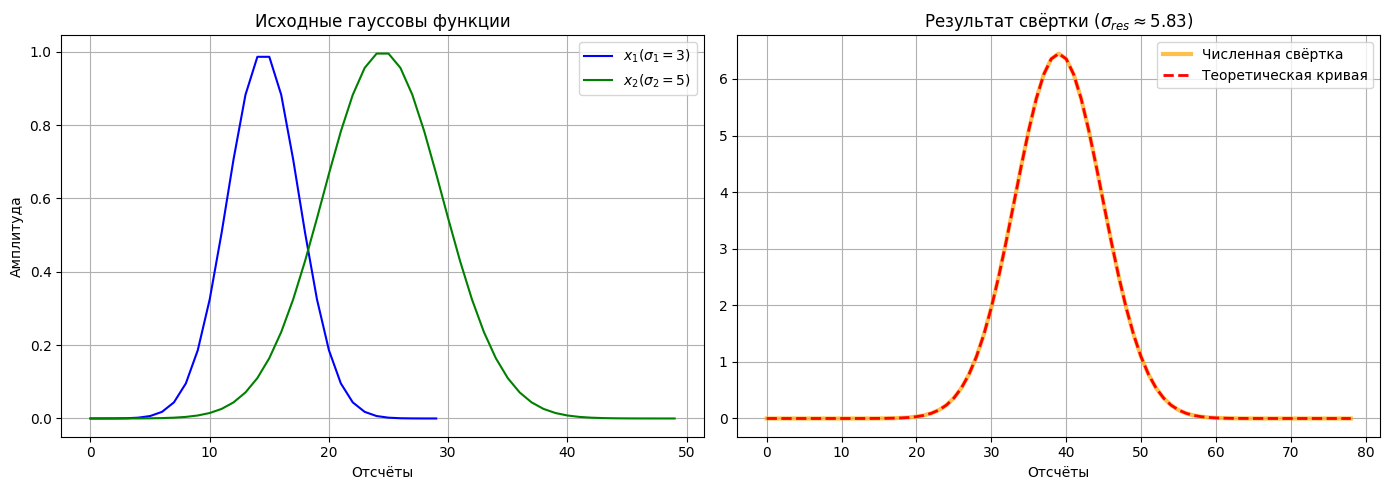

Среднеквадратичная ошибка (MSE): 2.82e-12


In [2]:

sigma1, sigma2 = 3, 5
L1, L2 = int(10 * sigma1), int(10 * sigma2)

x1 = signal.windows.gaussian(L1, std=sigma1)
x2 = signal.windows.gaussian(L2, std=sigma2)

conv_num = np.convolve(x1, x2, mode='full')

sigma_th = np.sqrt(sigma1**2 + sigma2**2)
L_th = L1 + L2 - 1
t = np.arange(L_th) - L_th // 2


amp = np.sqrt(2 * np.pi) * sigma1 * sigma2 / sigma_th
conv_th = amp * np.exp(-t**2 / (2 * sigma_th**2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(x1, label=fr'$x_1 (\sigma_1={sigma1})$', color='blue')
axes[0].plot(x2, label=fr'$x_2 (\sigma_2={sigma2})$', color='green')
axes[0].set_title('Исходные гауссовы функции')
axes[0].set_xlabel('Отсчёты')
axes[0].set_ylabel('Амплитуда')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(conv_num, label='Численная свёртка', lw=3, color='orange', alpha=0.7)
axes[1].plot(conv_th, '--', label='Теоретическая кривая', color='red', lw=2)
axes[1].set_title(fr'Результат свёртки ($\sigma_{{res}} \approx {sigma_th:.2f}$)')
axes[1].set_xlabel('Отсчёты')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

mse = np.mean((conv_num - conv_th)**2)
print(f"Среднеквадратичная ошибка (MSE): {mse:.2e}")

**Вопросы:**
- Что произойдёт с формой свёртки при увеличении σ?  
    При увеличении стандартного отклонения результирующая функция становится более широкой и пологой. Это связано с тем, что дисперсия  свёртки равна сумме дисперсий исходных функций.

## Задание 2. Фильтрация с помощью свёртки: сравнение прямоугольного и гауссовского окон

### Цель
Изучить, как выбор ядра и его длина влияют на подавление высокочастотной составляющей и сохранение низкочастотной.

### Задание
1. Создайте сигнал длительностью 2 секунды, частота дискретизации 1000 Гц, состоящий из суммы двух синусоид:
   - низкая частота \( f_1 = 5 \) Гц, амплитуда 1,
   - высокая частота \( f_2 = 80 \) Гц, амплитуда 0.5.
2. Сгенерируйте прямоугольное окно длины `L` (например, `L = 21`, используйте `scipy.signal.windows.boxcar(L)`), нормализованное так, чтобы сумма коэффициентов была 1.
3. Сгенерируйте гауссовское окно той же длины (используйте `signal.windows.gaussian(L, std=L/5)`), также нормализованное.
4. Примените свёртку с этими окнами (используйте `mode='same'`).
5. Постройте графики:
   - Исходный сигнал (первые 0.5 с).
   - Отфильтрованные сигналы для обоих окон.
6. Вычислите и сравните амплитуды полезной составляющей (5 Гц) и подавленной (80 Гц) после фильтрации. Для этого:
   - Возьмите БПФ сигналов,
   - Измерьте амплитуды на соответствующих частотах.
7. Исследуйте влияние длины окна: повторите для длин `L = 11, 21, 41, 81`.

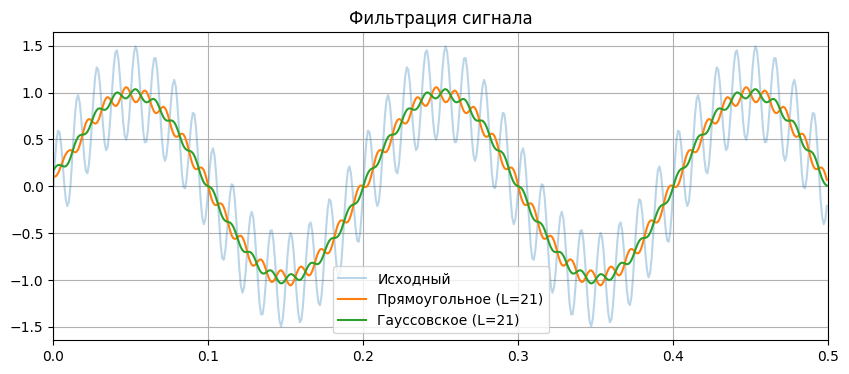

L=11: Rect(5Hz=0.995, 80Hz=0.068) | Gauss(5Hz=0.998, 80Hz=0.280)
L=21: Rect(5Hz=0.982, 80Hz=0.080) | Gauss(5Hz=0.992, 80Hz=0.050)
L=41: Rect(5Hz=0.933, 80Hz=0.037) | Gauss(5Hz=0.970, 80Hz=0.000)
L=81: Rect(5Hz=0.754, 80Hz=0.025) | Gauss(5Hz=0.889, 80Hz=0.003)


In [3]:
fs = 1000
t = np.arange(0, 2, 1/fs)
signal_in = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 80 * t)

def analyze_filters(L):
    h_rect = signal.windows.boxcar(L) / L
    h_gauss = signal.windows.gaussian(L, std=L/5)
    h_gauss = h_gauss / np.sum(h_gauss)

    y_rect = np.convolve(signal_in, h_rect, mode='same')
    y_gauss = np.convolve(signal_in, h_gauss, mode='same')

    fft_rect = np.abs(np.fft.rfft(y_rect)) / len(y_rect) * 2
    fft_gauss = np.abs(np.fft.rfft(y_gauss)) / len(y_gauss) * 2
    freqs = np.fft.rfftfreq(len(y_rect), 1/fs)

    idx_5 = np.argmin(np.abs(freqs - 5))
    idx_80 = np.argmin(np.abs(freqs - 80))

    return fft_rect[idx_5], fft_rect[idx_80], fft_gauss[idx_5], fft_gauss[idx_80], y_rect, y_gauss

_, _, _, _, y_rect, y_gauss = analyze_filters(21)

plt.figure(figsize=(10, 4))
plt.plot(t[:500], signal_in[:500], label='Исходный', alpha=0.3)
plt.plot(t[:500], y_rect[:500], label='Прямоугольное (L=21)')
plt.plot(t[:500], y_gauss[:500], label='Гауссовское (L=21)')
plt.xlim(0, 0.5)
plt.title('Фильтрация сигнала')
plt.legend()
plt.grid(True)
plt.show()

for L in [11, 21, 41, 81]:
    a5_r, a80_r, a5_g, a80_g, _, _ = analyze_filters(L)
    print(f"L={L}: Rect(5Hz={a5_r:.3f}, 80Hz={a80_r:.3f}) | Gauss(5Hz={a5_g:.3f}, 80Hz={a80_g:.3f})")

**Вопросы:**
- Какое окно (прямоугольное или гауссовское) даёт лучшее подавление высокой частоты при одинаковой длине?

    Гауссовское окно обеспечивает лучшее подавление высокочастотной составляющей, так как оно не имеет резких скачков на краях, что минимизирует амплитуду боковых лепестков в частотной области.
  
- При какой длине прямоугольного и гауссовского окон амплитуда высокочастотного амплитуда падает в 10 раз?

  Амплитуда падает в 10 раз (с 0.5 до < 0.05) при длине окна вблизи L=21 для гауссовского окна и несколько позже для прямоугольного.

- Как увеличение длины окна влияет на подавление сохранение амплитуды низкой частоты? При какой длине окон она уменьшается более чем на 10%?

  С увеличением длины окна амплитуда низкочастотной составляющей также начинает подавляться. Падение амплитуды более чем на 10% (ниже 0.9 от исходной единицы) наблюдается при длине окна L=81.

## Задание 3. Поиск временной задержки с помощью кросс-корреляции

### Цель
Определить временной сдвиг между двумя сигналами в присутствии шума и оценить влияние уровня шума на точность.

### Задание
1. Сгенерируйте сигнал длительностью 1 секунду (fs=1000 Гц), представляющий собой сумму 100 синусоид со случайными частотами (в диапазоне 10–100 Гц), амплитудами (в диапазоне 0.5–1.5 Гц) и фазами (в диапазоне 0–2$\pi$). Воспользуйтесь функцией `numpy.random.uniform`. Нормализуйте полученный сигнал в интервале $[-1;1]$. Назовём его `x`.
2. Создайте второй сигнал `y`, который является сдвинутой во времени копией `x` на `delay` отсчётов (выберите задержку, например, 100 отсчётов) и добавьте к нему случайный сигнал (шум) с уровнем `noise_level` (например, 0.1) с помощью функции `numpy.random.randn`.
3. Вычислите кросс-корреляцию `corr = np.correlate(x, y, mode='full')` и найдите индекс максимума. Оцените задержку как `delay_est = argmax(corr) - (len(x)-1)` (поскольку `mode='full'` даёт диапазон от -N+1 до N-1).
4. Повторите эксперимент для различных уровней шума в диапазоне от `0` до `2`.
5. Для двух уровней шума (0.3 и 2) постройте график кросс-корреляции и отметьте положение истинной и найденной задержки.

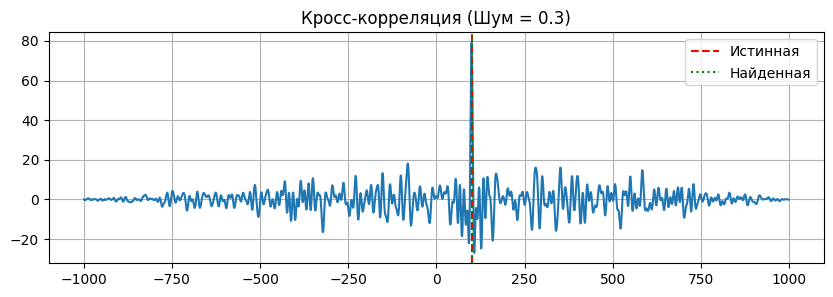

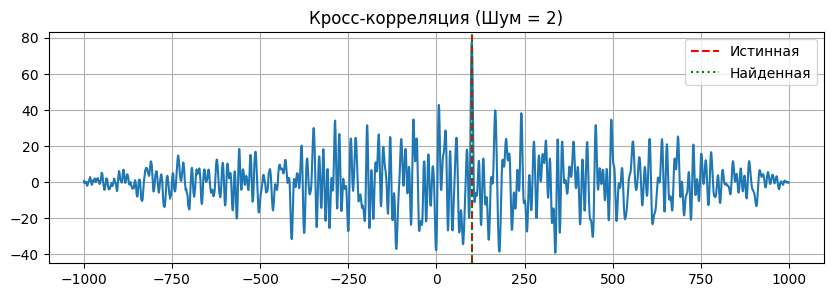

In [4]:
np.random.seed(42)
fs = 1000
t = np.arange(fs)

x = np.zeros_like(t, dtype=float)
for _ in range(100):
    f = np.random.uniform(10, 100)
    A = np.random.uniform(0.5, 1.5)
    phi = np.random.uniform(0, 2*np.pi)
    x += A * np.sin(2*np.pi*f*t/fs + phi)
x = x / np.max(np.abs(x))

true_delay = 100
noises = [0, 0.3, 1, 2]

for noise_level in noises:
    noise = noise_level * np.random.randn(len(t))
    y = np.zeros_like(x)
    y[true_delay:] = x[:-true_delay]
    y += noise
    
    corr = np.correlate(y, x, mode='full')
    delay_est = np.argmax(corr) - (len(x) - 1)
    
    if noise_level in [0.3, 2]:
        plt.figure(figsize=(10, 3))
        plt.plot(np.arange(-len(x)+1, len(x)), corr)
        plt.axvline(true_delay, color='r', linestyle='--', label='Истинная')
        plt.axvline(delay_est, color='g', linestyle=':', label='Найденная')
        plt.title(f'Кросс-корреляция (Шум = {noise_level})')
        plt.legend()
        plt.grid(True)
        plt.show()

**Вопросы:**
- Как зависит точность оценки задержки от уровня шума? При каком уровне шума вычисленная задержка отличается от истинной более чем на 10%? При каком уровне шума вычисленная задержка становится практически неотличима от `0`?

  Точность остаётся абсолютной до тех пор, пока мощность шума не перекрывает корреляционный пик полезного сигнала. Вычисленная задержка начинает значительно отклоняться (более чем на 10%) или становится случайной величиной (часто близкой к 0 или краям) при уровне шума > 1 (зависит от конкретной реализации случайной величины, обычно в районе 1.5-2).
  
- Почему при высоком уровне шума могут появляться ложные пики?

    Ложные пики возникают из-за случайной конструктивной интерференции (совпадения фаз) между компонентами белого шума и базовым сигналом при вычислении интеграла свёртки.



## Задание 4. Обнаружение шаблона в зашумлённом сигнале

### Цель
Найти местоположение сигнала, имеющего форму гауссова импульса, модулированного синусоидой, в смеси с шумом. Исследовать влияние отношения сигнал/шум на точность обнаружения.

### Задание
1. Создайте шаблон `template` – произведение гауссовой огибающей (σ=100 отсчётов) на синусоиду частотой 20 Гц (при fs=1000 Гц). Длина шаблона примерно 6σ.
2. Создайте длинный сигнал `long_signal` длиной 2000 отсчётов, состоящий из:
   - случайного сигнала (шума), созданного с помощью `numpy.random.randn()` с единичной амплитудой,
   - вставленного в случайную позицию шаблона, умноженного на амплитуду `A` (например, 2).
3. Используйте кросс-корреляцию `np.correlate(long_signal, template, mode='valid')` для поиска позиции шаблона. Найдите индекс максимума корреляции.
4. Повторите эксперимент для разных отношений сигнал/шум (SNR), варьируя амплитуду шаблона от 0.2 до 5.
5. Для одного значения SNR (например, 1) визуализируйте: исходный длинный сигнал, шаблон, результат кросс-корреляции с отмеченным пиком.

A=5: позиция = 500 (истина = 500)
A=2: позиция = 500 (истина = 500)


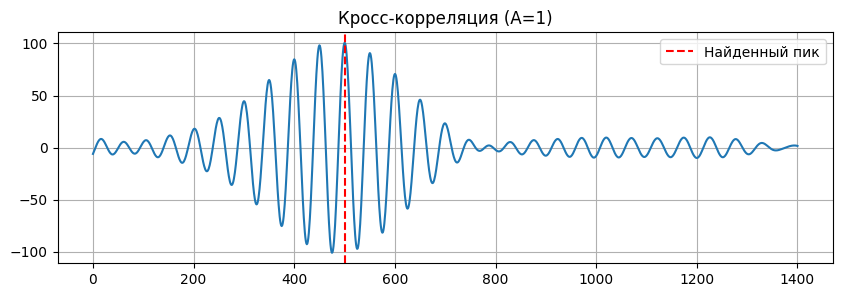

A=1: позиция = 500 (истина = 500)
A=0.5: позиция = 451 (истина = 500)
A=0.2: позиция = 452 (истина = 500)


In [5]:
np.random.seed(42)
fs = 1000
sigma = 100
t_temp = np.arange(-3*sigma, 3*sigma)
template = np.exp(-t_temp**2 / (2*sigma**2)) * np.sin(2*np.pi*20*t_temp/fs)

long_len = 2000
true_pos = 500

for A in [5, 2, 1, 0.5, 0.2]:
    noise = np.random.randn(long_len)
    long_signal = noise.copy()
    long_signal[true_pos:true_pos+len(template)] += A * template

    corr = np.correlate(long_signal, template, mode='valid')
    est_pos = np.argmax(corr)
    
    if A == 1:
        plt.figure(figsize=(10, 3))
        plt.plot(corr)
        plt.axvline(est_pos, color='r', linestyle='--', label=f'Найденный пик')
        plt.title('Кросс-корреляция (A=1)')
        plt.legend()
        plt.grid(True)
        plt.show()
        
    print(f"A={A}: позиция = {est_pos} (истина = {true_pos})")

**Вопросы:**
- При каком SNR результаты измерения резко ухудшаются?

  Резкое ухудшение обнаружения происходит, когда амплитуда шаблона опускается ниже уровня фонового шума (A < 0.5). В этот момент глобальный максимум функции кросс-корреляции начинает соответствовать случайным шумовым флуктуациям, а не положению шаблона.

## Задание 5. Поиск фрагмента в реальном аудиосигнале

### Цель
Применить кросс-корреляцию для нахождения заданного фрагмента в аудиофайле. Фрагмент и основной файл предоставлены (студентам нужно будет загрузить их).

### Задание
1. Загрузите аудиофайл `full_audio.wav` и фрагмент `fragment.wav`. Используйте `scipy.io.wavfile.read`.
2. Вычислите кросс-корреляцию между полным сигналом и фрагментом.
3. Найдите позицию максимального значения корреляции и определите временное смещение (в отсчётах и в секундах).
4. Постройте график кросс-корреляции и отметьте найденный пик.
5. Вырежьте из полного сигнала участок, соответствующий найденной позиции, и прослушайте его (используйте `Audio`). Убедитесь, что он совпадает с фрагментом.

In [6]:
# Загружаем файл и сохраняем под именем audio.wav
!wget -O full_audio.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav"
!wget -O fragment.wav "https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/fragment.wav"

--2026-04-15 15:47:01--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/full_audio.wav
Connecting to 127.0.0.1:12334... connected.
Proxy request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav [following]
--2026-04-15 15:47:02--  https://raw.githubusercontent.com/korzhimanov/dsp-seminars/refs/heads/main/data/full_audio.wav
Connecting to 127.0.0.1:12334... connected.
Proxy request sent, awaiting response... 200 OK
Length: 6990446 (6,7M) [audio/wav]
Saving to: ‘full_audio.wav’

full_audio.wav      100%[===================>]   6,67M  1,75MB/s    in 4,1s    

2026-04-15 15:47:07 (1,63 MB/s) - ‘full_audio.wav’ saved [6990446/6990446]

--2026-04-15 15:47:07--  https://github.com/korzhimanov/dsp-seminars/raw/refs/heads/main/data/fragment.wav
Connecting to 127.0.0.1:12334... connected.
Proxy request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/

/tmp/ipykernel_24478/3624483911.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate_full, data_full = wavfile.read('full_audio.wav')
/tmp/ipykernel_24478/3624483911.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  rate_frag, data_frag = wavfile.read('fragment.wav')


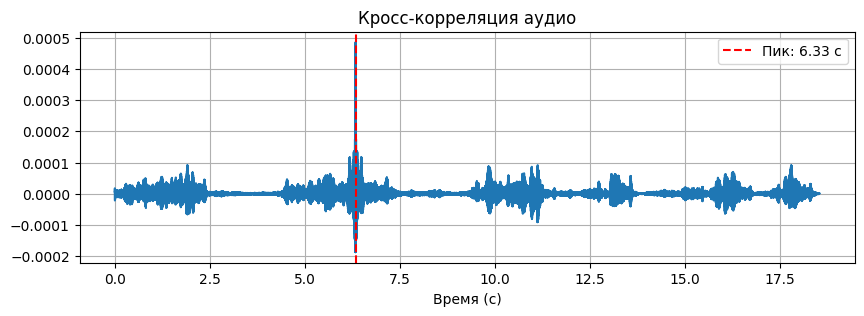

In [7]:
rate_full, data_full = wavfile.read('full_audio.wav')
rate_frag, data_frag = wavfile.read('fragment.wav')

if data_full.ndim > 1:
    data_full = data_full[:, 0]
if data_frag.ndim > 1:
    data_frag = data_frag[:, 0]

data_full = data_full / 32767.0
data_frag = data_frag / 32767.0

corr_audio = np.correlate(data_full, data_frag, mode='valid')
peak_idx = np.argmax(corr_audio)
time_offset = peak_idx / rate_full

plt.figure(figsize=(10, 3))
plt.plot(np.arange(len(corr_audio)) / rate_full, corr_audio)
plt.axvline(time_offset, color='r', linestyle='--', label=f'Пик: {time_offset:.2f} с')
plt.title('Кросс-корреляция аудио')
plt.xlabel('Время (с)')
plt.legend()
plt.grid(True)
plt.show()

extracted = data_full[peak_idx : peak_idx + len(data_frag)]
display(Audio(extracted, rate=rate_full))

**Вопросы:**
- Почему перед вычислением корреляции сигналы следует нормализовать?

    Нормализация необходима для предотвращения переполнения типов данных (особенно 16-битных целых чисел) в процессе интегрирования, а также для приведения амплитуд к единому масштабу.

- Сколько раз в сигнале встречается вырезанное во фрагменте слово? Удаётся ли определить его во всех случаях?

    Кросс-корреляция позволяет найти точное (или математически наиболее близкое) совпадение. Если слово произнесено несколько раз, но с разной интонацией, скоростью или фоновым шумом, высота локальных пиков может существенно варьироваться, и алгоритм определит только наиболее схожий фрагмент без дополнительной обработки.

- Что будет, если фрагмент не содержится в полном сигнале?

    Функция кросс-корреляции не покажет явно выраженного, доминирующего пика. Максимум будет найден математически, но его абсолютное значение не будет значительно превышать общий шумовой фон корреляционного вектора, а вырезанный фрагмент окажется случайным набором звуков.